In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Build the RFM feature table 
for each user: 
- Recency (days since last transaction), 
- Frequency (transaction count), 
- Monetary (total or avg amount). 

In [205]:
df = pd.read_csv("rfm_features_csv.csv")

In [3]:
df.head()

,user_id,signup_date,city,state,acquisition_channel,age_bucket,kyc_status,is_churned,recency_days,frequency,total_amount,avg_amount
0,1,2024-03-06,Bengaluru,Karnataka,Merchant Partner,18-24,Full KYC,0,37.0,17,6993.46,411.38
1,2,2025-07-18,Kolkata,West Bengal,Bank Partnership,18-24,Full KYC,1,114.0,1,986.95,986.95
2,3,2025-04-22,Hyderabad,Telangana,Organic,18-24,Full KYC,0,109.0,9,6646.13,738.46
3,4,2024-11-16,Ahmedabad,Gujarat,Merchant Partner,35-44,Pending,0,418.0,2,479.21,239.61
4,5,2024-11-12,Kolkata,West Bengal,Referral,35-44,Full KYC,0,4.0,6,2703.09,450.52


In [4]:
df.shape

(25000, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              25000 non-null  int64  
 1   signup_date          25000 non-null  object 
 2   city                 25000 non-null  object 
 3   state                25000 non-null  object 
 4   acquisition_channel  25000 non-null  object 
 5   age_bucket           25000 non-null  object 
 6   kyc_status           25000 non-null  object 
 7   is_churned           25000 non-null  int64  
 8   recency_days         24463 non-null  float64
 9   frequency            25000 non-null  int64  
 10  total_amount         24463 non-null  float64
 11  avg_amount           24463 non-null  float64
dtypes: float64(3), int64(3), object(6)
memory usage: 2.3+ MB


In [6]:
df['signup_date'] = pd.to_datetime(df['signup_date'])

In [7]:
df.dtypes

user_id                         int64
signup_date            datetime64[ns]
city                           object
state                          object
acquisition_channel            object
age_bucket                     object
kyc_status                     object
is_churned                      int64
recency_days                  float64
frequency                       int64
total_amount                  float64
avg_amount                    float64
dtype: object

In [8]:
df['is_churned'].value_counts()

is_churned
0    20533
1     4467
Name: count, dtype: int64

In [9]:
df.isnull().sum()

user_id                  0
signup_date              0
city                     0
state                    0
acquisition_channel      0
age_bucket               0
kyc_status               0
is_churned               0
recency_days           537
frequency                0
total_amount           537
avg_amount             537
dtype: int64

### separate users who never transacted (nulls in RFM columns)

In [104]:
never_transacted = df[df['recency_days'].isnull()].copy()

rfm = df[df['recency_days'].notnull()].copy()

In [11]:
print(f"Total users: {len(df)}")
print(f"Never transacted: {len(never_transacted)}")
print(f"Scoring RFM for: {len(rfm)} users")

Total users: 25000
Never transacted: 537
Scoring RFM for: 24463 users


In [105]:
# Step 2: quartile scoring
# Recency: LOWER days = MORE active = should get a HIGHER score
rfm['R_score'] = pd.qcut(rfm['recency_days'].rank(method='first'), q=4, labels=[4, 3, 2, 1]).astype(int)

# Frequency: HIGHER count = MORE engaged = HIGHER score
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)

# Monetary: HIGHER spend = MORE valuable = HIGHER score
rfm['M_score'] = pd.qcut(rfm['total_amount'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)


In [106]:
rfm[['user_id', 'recency_days', 'frequency', 'total_amount',
           'R_score', 'F_score', 'M_score']].head(10)

,user_id,recency_days,frequency,total_amount,R_score,F_score,M_score
0,1,37.0,17,6993.46,2,2,2
1,2,114.0,1,986.95,1,1,1
2,3,109.0,9,6646.13,1,2,2
3,4,418.0,2,479.21,1,1,1
4,5,4.0,6,2703.09,4,1,1
5,6,59.0,1,850.65,2,1,1
6,7,1.0,194,99302.34,4,4,4
7,8,35.0,50,26968.33,2,4,4
8,9,3.0,51,34526.78,4,4,4
9,10,15.0,83,39247.95,3,4,4


In [107]:
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    
    if r >= 3 and f >= 3 and m >= 3:
        return 'VIP / Champions'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Dormant'
    elif r >= 3 and f <= 2:
        return 'New & Promising'
    elif r <= 2 and (f >= 3 or m >= 3):
        return 'At Risk'   
    else:
        return 'Mid-tier' 

rfm['segment'] = rfm.apply(assign_segment, axis=1)

In [108]:

rfm['segment'].value_counts()


segment
VIP / Champions    8827
Dormant            8725
At Risk            3506
New & Promising    2901
Mid-tier            504
Name: count, dtype: int64

In [109]:
rfm.groupby('segment')[['recency_days', 'frequency', 'total_amount']].mean().round(1)

,recency_days,frequency,total_amount
segment,,,
At Risk,50.0,27.0,15216.8
Dormant,143.9,6.7,3239.7
Mid-tier,10.2,19.7,7493.5
New & Promising,10.9,10.2,5449.7
VIP / Champions,7.4,84.6,45291.7


In [110]:
def changer(segment):
    if segment == 'Mid-tier':
        return 'New & Promising'
    else :
        return segment
rfm['segment'] = rfm['segment'].apply(changer)

In [111]:
rfm.groupby('segment')[['recency_days', 'frequency', 'total_amount']].mean().round(1)

,recency_days,frequency,total_amount
segment,,,
At Risk,50.0,27.0,15216.8
Dormant,143.9,6.7,3239.7
New & Promising,10.8,11.6,5752.2
VIP / Champions,7.4,84.6,45291.7


In [112]:
# label the never-transacted users as their own segment
never_transacted['segment'] = 'Never Activated'

# combine back into one full dataset

common_cols = ['user_id', 'recency_days', 'frequency', 'total_amount', 'segment']
full_rfm = pd.concat([
    rfm[common_cols],
    never_transacted[common_cols]
], ignore_index=True)


In [114]:
full_rfm['segment'].value_counts()


segment
VIP / Champions    8827
Dormant            8725
At Risk            3506
New & Promising    3405
Never Activated     537
Name: count, dtype: int64

<Axes: xlabel='segment'>

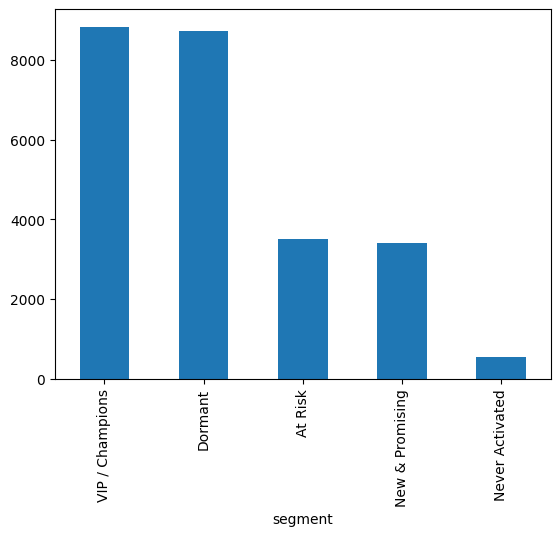

In [116]:
full_rfm['segment'].value_counts().plot(kind='bar')

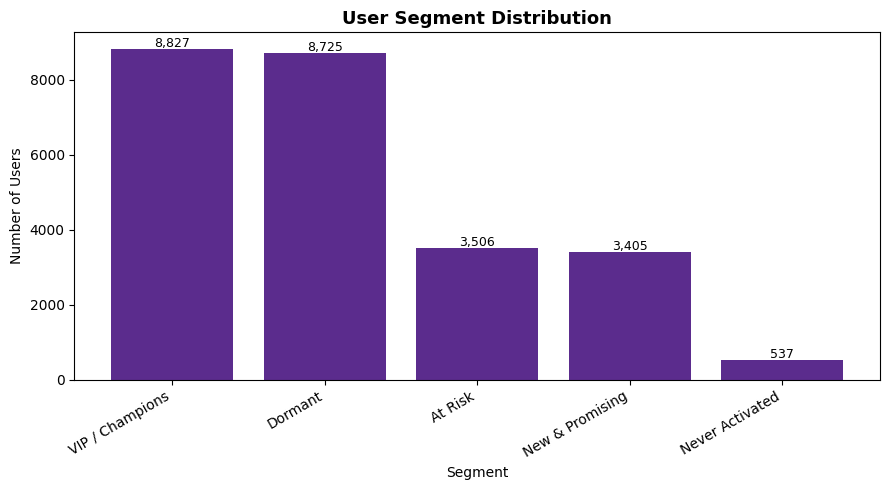

In [117]:
segment_counts = full_rfm['segment'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(segment_counts.index, segment_counts.values, color='#5B2C8D')
plt.title('User Segment Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Users')
plt.xticks(rotation=30, ha='right')

# label each bar with its count - makes the chart readable standalone
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50, f'{int(height):,}',
              ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150)
plt.show()

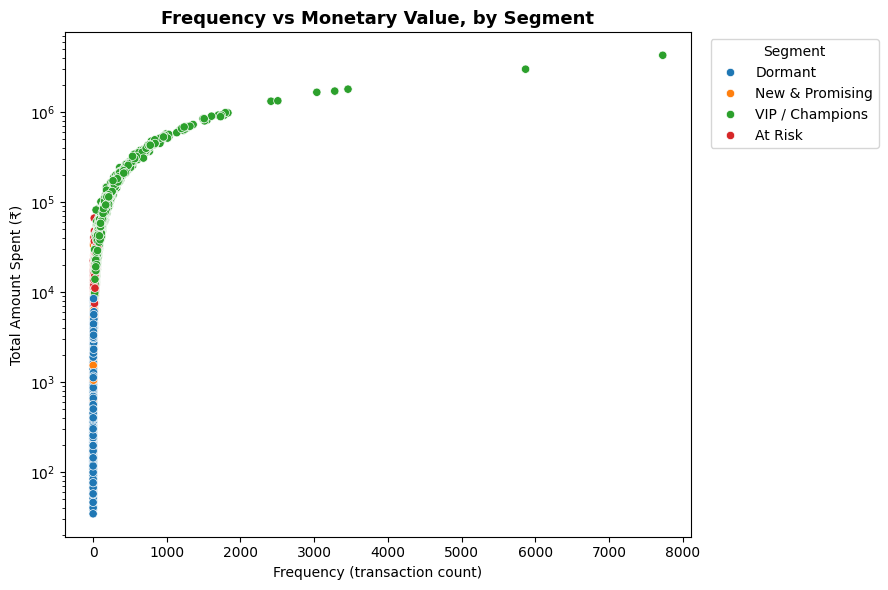

In [118]:
d1 = full_rfm[full_rfm['segment']!= "Never Activated"]
plt.figure(figsize=(9, 6))
sns.scatterplot(data=d1 , x= "frequency",y = 'total_amount',hue='segment')

plt.yscale('log')
plt.xlabel('Frequency (transaction count)')
plt.ylabel('Total Amount Spent (₹)')
plt.title('Frequency vs Monetary Value, by Segment', fontsize=13, fontweight='bold')
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('freq_vs_monetary_scatter.png', dpi=150)
plt.show()

# K-means clustring

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [121]:
rfm.head()

,user_id,signup_date,city,state,acquisition_channel,age_bucket,kyc_status,is_churned,recency_days,frequency,total_amount,avg_amount,R_score,F_score,M_score,segment
0,1,2024-03-06,Bengaluru,Karnataka,Merchant Partner,18-24,Full KYC,0,37.0,17,6993.46,411.38,2,2,2,Dormant
1,2,2025-07-18,Kolkata,West Bengal,Bank Partnership,18-24,Full KYC,1,114.0,1,986.95,986.95,1,1,1,Dormant
2,3,2025-04-22,Hyderabad,Telangana,Organic,18-24,Full KYC,0,109.0,9,6646.13,738.46,1,2,2,Dormant
3,4,2024-11-16,Ahmedabad,Gujarat,Merchant Partner,35-44,Pending,0,418.0,2,479.21,239.61,1,1,1,Dormant
4,5,2024-11-12,Kolkata,West Bengal,Referral,35-44,Full KYC,0,4.0,6,2703.09,450.52,4,1,1,New & Promising


In [155]:
X =rfm[['recency_days','frequency','total_amount']].copy()


<Axes: xlabel='recency_days', ylabel='Count'>

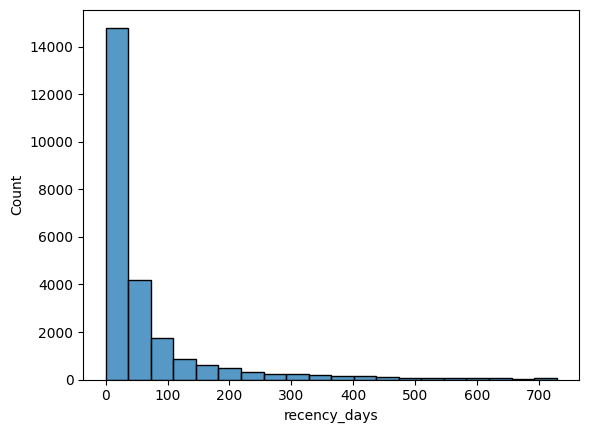

In [134]:
sns.histplot(rfm['recency_days'],bins=20)

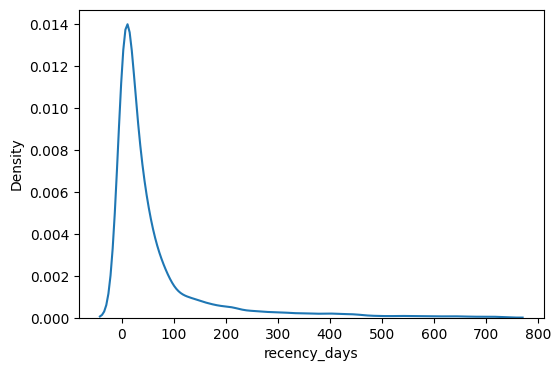

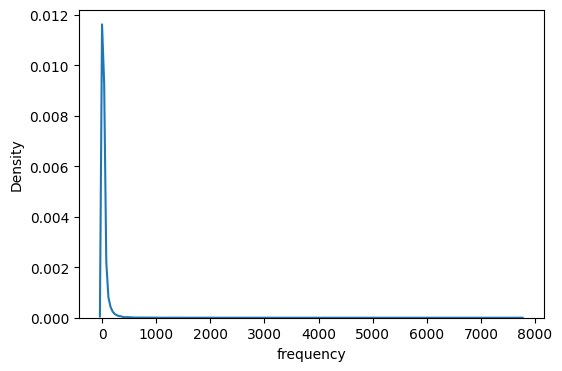

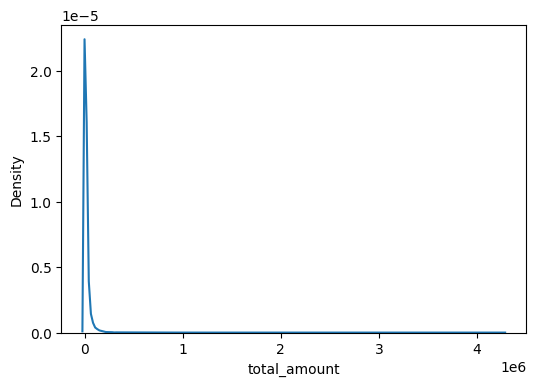

In [123]:

for col in X.columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(X[col])
    

In [ ]:
X['frequency'] = np.log1p(X['frequency'])
X['total_amount'] = np.log1p(X['total_amount'])
X['recency_days'] = np.log1p(X['recency_days'])


<Axes: xlabel='frequency', ylabel='Density'>

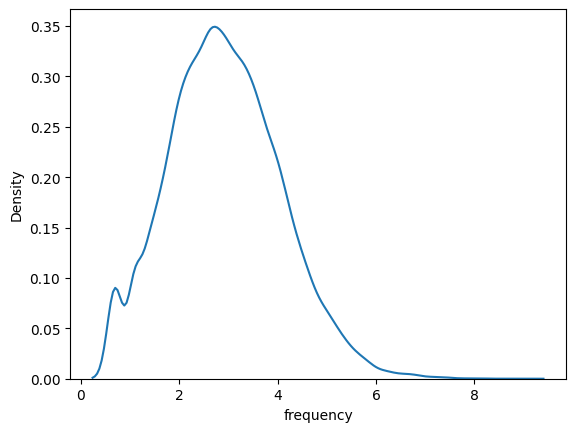

In [136]:
sns.kdeplot(X['frequency'])

In [158]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [159]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

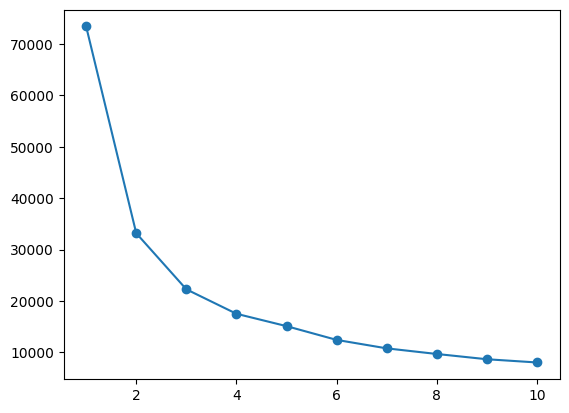

In [160]:
plt.plot(K_range, inertia, marker='o')

### K = 4
- inertia drop flattens noticeably after k=4, diminishing returns beyond this point

In [161]:
kmeans_final = KMeans(n_clusters=4, random_state=42)

In [162]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [163]:
X['segment'] = cluster_labels

In [35]:
import plotly.express as px

In [143]:
px.scatter_3d(X, x = X['frequency'],y =  X['recency_days'], z = X['total_amount'],color=X['segment'],opacity=0.8)

In [164]:
X.groupby('segment')[['recency_days','frequency','total_amount']].mean()

,recency_days,frequency,total_amount
segment,,,
0,1.206343,4.707684,10.979067
1,3.757633,2.421565,8.531954
2,5.115647,1.344282,6.916964
3,2.388574,3.405221,9.635653


#### segemnts  "VIP," "At Risk," "New & Promising," "Dormant"
###### 1 -> At Risk
###### 0 -> VIP
###### 3 -> New & Promising
###### 2 -> Dormant

In [165]:
X['segment'] = X['segment'].map({1 : 'At Risk', 0 : 'VIP', 3 : 'New & Promising' , 2 : 'Dormant'})

In [166]:
rfm['kmeans_segment'] = X['segment']

In [167]:
rfm.groupby('kmeans_segment')[['recency_days','frequency','total_amount']].mean()

,recency_days,frequency,total_amount
kmeans_segment,,,
At Risk,57.258456,11.265174,5864.358966
Dormant,227.514143,3.191489,1380.805046
New & Promising,15.029933,32.162981,17235.090701
VIP,3.873354,149.537651,80212.605063


In [154]:
rfm.groupby('segment')[['recency_days','frequency','total_amount']].mean()

,recency_days,frequency,total_amount
segment,,,
At Risk,50.002282,26.991443,15216.776908
Dormant,143.851576,6.748768,3239.687840
New & Promising,10.757709,11.564464,5752.174396
VIP / Champions,7.414184,84.586043,45291.678186


In [168]:
rfm['kmeans_segment'].value_counts()


kmeans_segment
At Risk            8485
New & Promising    8185
Dormant            3995
VIP                3798
Name: count, dtype: int64

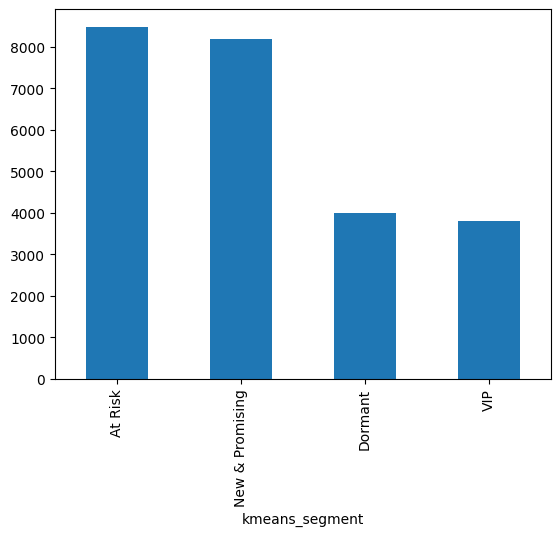

In [170]:
fig = rfm['kmeans_segment'].value_counts().plot(kind='bar')
plt.savefig('cluster_distribution.png', dpi=150)
plt.show()

In [ ]:
rfm['segment'].value_counts().to_csv('dashboard/segment.csv')


In [ ]:
rfm['kmeans_segment'].value_counts().to_csv('dashboard/kmeans_segment.csv')

In [ ]:
comparison = pd.crosstab(rfm['segment'], rfm['kmeans_segment'],margins=True)
print(comparison)
comparison.to_csv("dashboard/comparison.csv")

kmeans_segment   At Risk  Dormant  New & Promising   VIP    All
segment                                                        
At Risk             1770        3             1717    16   3506
Dormant             4835     3890                0     0   8725
New & Promising     1876      102             1427     0   3405
VIP / Champions        4        0             5041  3782   8827
All                 8485     3995             8185  3798  24463


In [175]:
rfm.columns

Index(['user_id', 'signup_date', 'city', 'state', 'acquisition_channel',
       'age_bucket', 'kyc_status', 'is_churned', 'recency_days', 'frequency',
       'total_amount', 'avg_amount', 'R_score', 'F_score', 'M_score',
       'segment', 'kmeans_segment'],
      dtype='object')

In [181]:
df2 = rfm.groupby('kmeans_segment').agg(
    {
        'kmeans_segment':'count',
        'recency_days' : 'mean',
        'frequency' : 'mean',
        'total_amount' : 'mean',
        'is_churned' : 'sum'

    }
)

In [184]:
def process(row):
    val1 = str(round((row['kmeans_segment']/df2['kmeans_segment'].sum()) * 100,1)) + '%'
    val2 = str(round((row['is_churned']/df2['is_churned'].sum()) * 100,1)) + '%'
    row['share'] = val1
    row['churn_rate'] = val2
    return row

In [189]:
df3 = df2.apply(process , axis=1).rename(columns ={
                                    'kmeans_segment':'customer',
                                    'recency_days' : 'avg recency days',
                                    'frequency' : 'avg frequency',
                                    'total_amount': 'avg monetary',
                                    'churn_rate' : 'churn rate'
                                    })[['customer','share','avg recency days','avg frequency','avg monetary','churn rate']]

In [ ]:
df3.to_csv('dashboard/Kmeans_segmentation.csv')
df3

,customer,share,avg recency days,avg frequency,avg monetary,churn rate
kmeans_segment,,,,,,
At Risk,8485.0,34.7%,57.258456,11.265174,5864.358966,31.2%
Dormant,3995.0,16.3%,227.514143,3.191489,1380.805046,58.7%
New & Promising,8185.0,33.5%,15.029933,32.162981,17235.090701,8.8%
VIP,3798.0,15.5%,3.873354,149.537651,80212.605063,1.2%


In [194]:
df4 = rfm.groupby('segment').agg(
    {
        'segment':'count',
        'recency_days' : 'mean',
        'frequency' : 'mean',
        'total_amount' : 'mean',
        'is_churned' : 'sum'

    }
)

def process(row):
    val1 = str(round((row['segment']/df4['segment'].sum()) * 100,1)) + '%'
    val2 = str(round((row['is_churned']/df4['is_churned'].sum()) * 100,1)) + '%'
    row['share'] = val1
    row['churn_rate'] = val2
    return row

df5 = df4.apply(process , axis=1).rename(columns ={
                                    'segment':'customer',
                                    'recency_days' : 'avg recency days',
                                    'frequency' : 'avg frequency',
                                    'total_amount': 'avg monetary',
                                    'churn_rate' : 'churn rate'
                                    })[['customer','share','avg recency days','avg frequency','avg monetary','churn rate']]


In [ ]:
df5.to_csv('dashboard/rule_based_segmentation.csv')
df5

,customer,share,avg recency days,avg frequency,avg monetary,churn rate
segment,,,,,,
At Risk,3506.0,14.3%,50.002282,26.991443,15216.776908,4.8%
Dormant,8725.0,35.7%,143.851576,6.748768,3239.687840,76.1%
New & Promising,3405.0,13.9%,10.757709,11.564464,5752.174396,13.9%
VIP / Champions,8827.0,36.1%,7.414184,84.586043,45291.678186,5.3%
